V data shape: (5196, 6113)
Minimum value: -9999.0
Maximum value: 1.1062523
H data shape: (5196, 6113)
Minimum value: -9999.0
Maximum value: 3.2947693


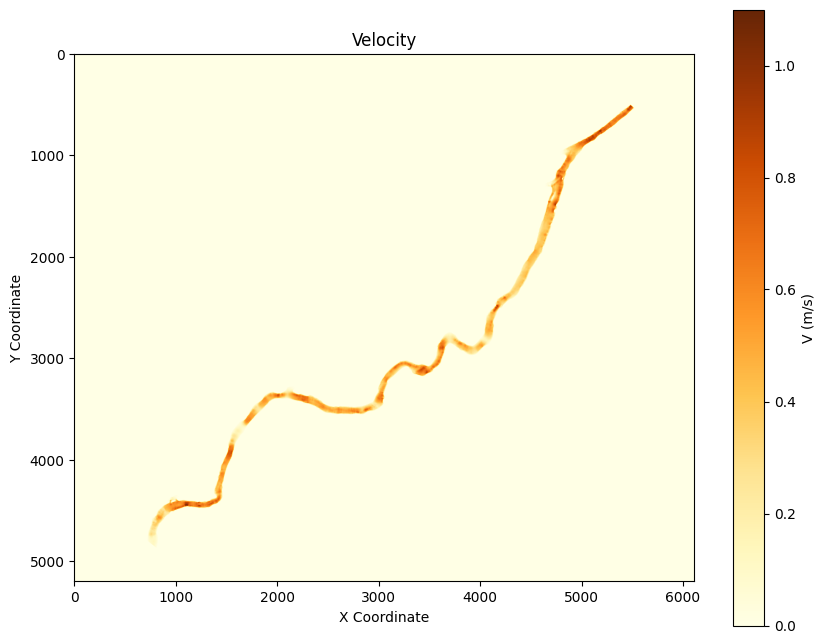

In [1]:
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np

# Read V DEM data
dem_dataV = tiff.imread('Vx.tif')

# Check data shape and range
print("V data shape:", dem_dataV.shape)
print("Minimum value:", np.nanmin(dem_dataV))
print("Maximum value:", np.nanmax(dem_dataV))

# Handle invalid values (if any)
dem_dataV = np.nan_to_num(dem_dataV, nan=0)
dem_dataV = np.where(dem_dataV < 0, 0, dem_dataV)

# If it's multi-band data, extract the first band
if dem_dataV.ndim == 3:
    dem_dataV = dem_dataV[0]
V1 = dem_dataV[3250:1350,2000:1250]

# Read H DEM data
dem_dataH = tiff.imread('Hx.tif')

# Check data shape and range
print("H data shape:", dem_dataH.shape)
print("Minimum value:", np.nanmin(dem_dataH))
print("Maximum value:", np.nanmax(dem_dataH))

# Handle invalid values (if any)
dem_dataH = np.nan_to_num(dem_dataH, nan=0)
dem_dataH = np.where(dem_dataH < 0, 0, dem_dataH)

# If it's multi-band data, extract the first band
if dem_dataH.ndim == 3:
    dem_dataH = dem_dataH[0]

# Visualize DEM data
plt.figure(figsize=(10, 8))
plt.imshow(dem_dataV, cmap='YlOrBr', vmin=0, vmax=1.1)
# plt.imshow(V1, cmap='YlOrBr', vmin=0, vmax=1.1)
cbar = plt.colorbar(label='V (m/s)')
plt.title('Velocity')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

In [2]:
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np

# Read DEM data
dem_dataV = tiff.imread('Vx.tif')
dem_dataH = tiff.imread('Hx.tif')

# Handle invalid values (if any)
dem_dataV = np.nan_to_num(dem_dataV, nan=0)
dem_dataV = np.where(dem_dataV < 0, 0, dem_dataV)
dem_dataH = np.nan_to_num(dem_dataH, nan=0)
dem_dataH = np.where(dem_dataH < 0, 0, dem_dataH)
# If it's multi-band data, extract the first band
if dem_dataV.ndim == 3:
    dem_dataV = dem_dataV[0]
    dem_dataH = dem_dataH[0]

V1 = dem_dataV[3300:4200,1400:1900]
H1 = dem_dataH[3300:4200,1400:1900]

# V1 = dem_dataV[3400:3600,2500:2800]
# H1 = dem_dataH[3400:3600,2500:2800]

# V1 = dem_dataV[1900:2300,4250:4700]
# H1 = dem_dataH[1900:2300,4250:4700]

# V1 = dem_dataV[500:900,5050:5550]
# H1 = dem_dataH[500:900,5050:5550]

# Check data shape and range
print("Data shape Vx:", dem_dataV.shape)
print("Data shape V1:", V1.shape)

Data shape Vx: (5196, 6113)
Data shape V1: (900, 500)


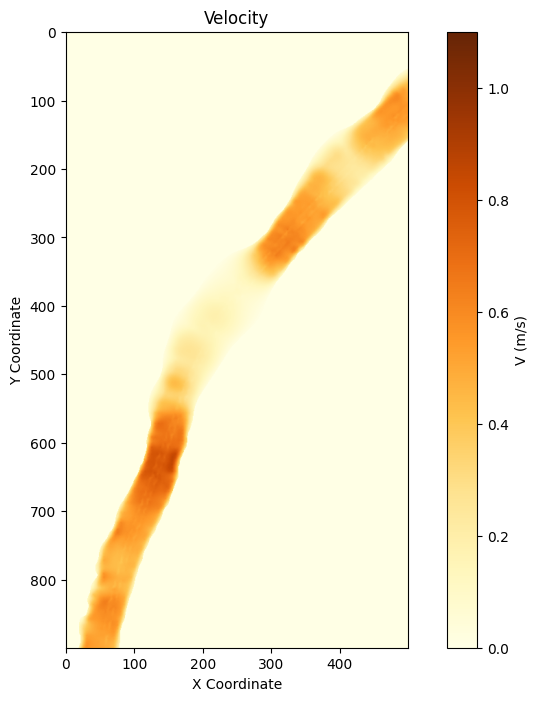

In [3]:
plt.figure(figsize=(10, 8))
# plt.imshow(dem_dataV, cmap='YlOrBr', vmin=0, vmax=1.1)
plt.imshow(V1, cmap='YlOrBr', vmin=0, vmax=1.1)
cbar = plt.colorbar(label='V (m/s)')
plt.title('Velocity')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

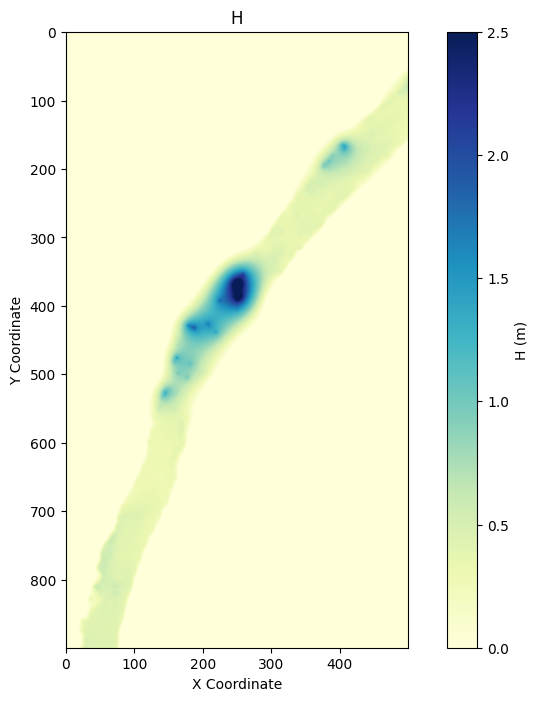

In [4]:
plt.figure(figsize=(10, 8))
# plt.imshow(dem_dataV, cmap='YlOrBr', vmin=0, vmax=1.1)
plt.imshow(H1, cmap='YlGnBu', vmin=0, vmax=2.5)
cbar = plt.colorbar(label='H (m)')
plt.title('H')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

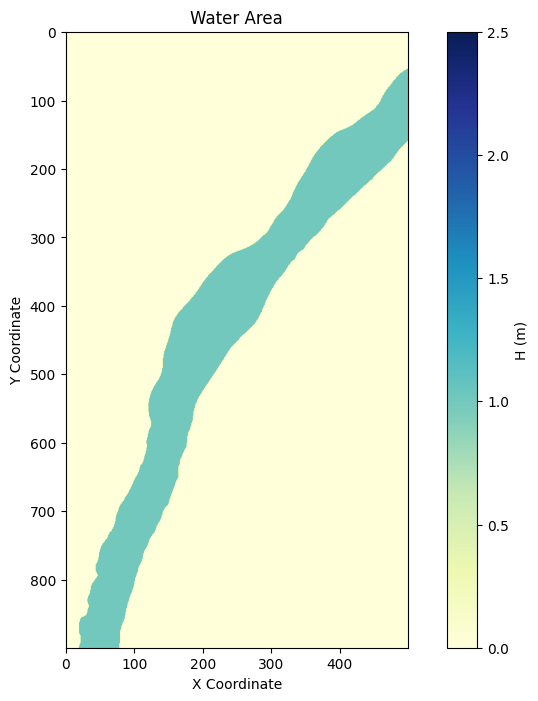

In [5]:
from skimage import morphology, measure
WaterArea = V1.copy()
WaterArea = np.where(V1 < 0.01, 0, 1)
skeleton = morphology.skeletonize(WaterArea)
plt.figure(figsize=(10, 8))
# plt.imshow(dem_dataV, cmap='YlOrBr', vmin=0, vmax=1.1)
plt.imshow(WaterArea, cmap='YlGnBu', vmin=0, vmax=2.5)
cbar = plt.colorbar(label='H (m)')
plt.title('Water Area')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

centerline points number: 875
cross section number: 50


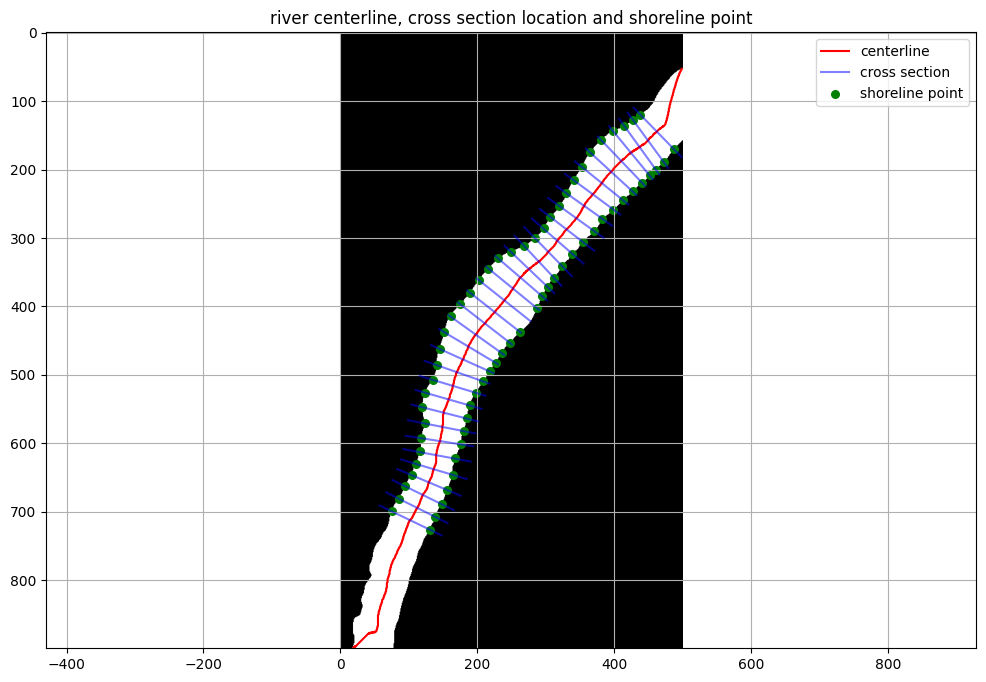

In [6]:
import numpy as np
from scipy.interpolate import splprep, splev
from scipy.spatial import distance

from skimage import morphology, measure
import matplotlib.pyplot as plt

# 1. Extract river centerline
# Use skeletonization algorithm to extract centerline
WaterArea = V1.copy()
WaterArea = np.where(V1 < 0.01, 0, 1)
skeleton = morphology.skeletonize(WaterArea)

# 2. Get coordinates of centerline points
y_coords, x_coords = np.where(skeleton == True)
centerline_points = np.column_stack((x_coords, y_coords))

def smooth_centerline(points, smoothing_factor=1000, num_points=1000):
    """
    Smooth the centerline using B-spline
    points: original centerline points
    smoothing_factor: degree of smoothing; larger values produce smoother results
    num_points: number of interpolated points
    """
    # Remove duplicate points
    diff = np.diff(points, axis=0)
    mask = np.ones(len(points), dtype=bool)
    mask[1:] = (diff != 0).any(axis=1)
    points = points[mask]
    
    # Compute cumulative distance as parameter
    dist = np.cumsum(np.sqrt(np.sum(np.diff(points, axis=0)**2, axis=1)))
    dist = np.insert(dist, 0, 0)
    
    # B-spline interpolation
    tck, u = splprep([points[:,0], points[:,1]], u=dist, s=smoothing_factor, per=False)
    
    # Generate new smoothed points
    u_new = np.linspace(dist.min(), dist.max(), num_points)
    smooth_points = np.array(splev(u_new, tck)).T
    
    return smooth_points

def generate_perpendicular_vectors(smooth_points):
    """
    Compute perpendicular vectors at each point along the smoothed centerline
    """
    # Compute tangent vectors
    tangent_vectors = np.diff(smooth_points, axis=0)
    # Append the last tangent vector to match point count
    tangent_vectors = np.vstack([tangent_vectors, tangent_vectors[-1]])
    
    # Normalize tangent vectors
    norms = np.sqrt(np.sum(tangent_vectors**2, axis=1))
    tangent_vectors = tangent_vectors / norms[:, np.newaxis]
    
    # Compute perpendicular vectors (-dy, dx)
    perpendicular_vectors = np.array([-tangent_vectors[:,1], tangent_vectors[:,0]]).T
    
    return perpendicular_vectors

def generate_smooth_cross_sections(smooth_points, perpendicular_vectors, length=50, spacing_points=20):
    """
    Generate cross-sections based on the smoothed centerline
    """
    cross_sections = []
    
    # Generate a cross-section every spacing_points points
    for i in range(0, len(smooth_points), spacing_points):
        point = smooth_points[i]
        perp_vector = perpendicular_vectors[i]
        
        # Generate endpoints of the cross-section
        left_point = point - perp_vector * length
        right_point = point + perp_vector * length
        
        cross_sections.append((left_point, right_point))
    
    return cross_sections

# Smooth the centerline
smooth_centerline_points = smooth_centerline(centerline_points, 
                                           smoothing_factor=1000, 
                                           num_points=1000)

# Compute perpendicular vectors
perpendicular_vectors = generate_perpendicular_vectors(smooth_centerline_points)

# Generate new cross-sections
smooth_cross_sections = generate_smooth_cross_sections(smooth_centerline_points, 
                                                     perpendicular_vectors,
                                                     length=50, 
                                                     spacing_points=20)

# Save smoothed results
smooth_results = {
    'smooth_centerline': smooth_centerline_points,
    'smooth_cross_sections': smooth_cross_sections
}
# np.save('smooth_river_analysis.npy', smooth_results)

# Calculate and display curvature
def calculate_curvature(points):
    """Calculate curvature of a curve"""
    dx_dt = np.gradient(points[:, 0])
    dy_dt = np.gradient(points[:, 1])
    d2x_dt2 = np.gradient(dx_dt)
    d2y_dt2 = np.gradient(dy_dt)
    curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / \
                (dx_dt * dx_dt + dy_dt * dy_dt)**1.5
    return curvature

# Calculate curvature for original and smoothed centerlines
original_curvature = calculate_curvature(centerline_points)
smooth_curvature = calculate_curvature(smooth_centerline_points)

# 5. Save cross-section coordinates
cross_section_coordinates = {
    'centerline': centerline_points,
    'cross_sections': smooth_cross_sections
}

# Save coordinates to file if needed
# np.save('river_coordinates.npy', cross_section_coordinates)

# Print basic information
print(f"centerline points number: {len(centerline_points)}")
print(f"cross section number: {len(smooth_cross_sections)}")

# 6. Obtain intersection points between each cross-section and the water area (actual shoreline positions)
def get_intersection_points(cross_section, water_area):
    """
    Get intersection points between a cross-section line and the water area
    """
    left, right = cross_section
    points = []
    
    # Sample points along the cross-section line
    num_samples = 1000
    x = np.linspace(left[0], right[0], num_samples)
    y = np.linspace(left[1], right[1], num_samples)
    
    # Convert to integer coordinates
    x = x.astype(int)
    y = y.astype(int)
    
    # Ensure coordinates are within image bounds
    mask = (x >= 0) & (x < water_area.shape[1]) & (y >= 0) & (y < water_area.shape[0])
    x = x[mask]
    y = y[mask]
    
    # Get water area values along the cross-section
    values = water_area[y, x]
    
    # Find positions where values change (water-land boundaries)
    changes = np.where(np.diff(values) != 0)[0]
    
    for idx in changes:
        points.append((x[idx], y[idx]))
    
    return points

# Get intersection points for all cross-sections
intersection_points = []
for cross_section in smooth_cross_sections:
    points = get_intersection_points(cross_section, WaterArea)
    intersection_points.append(points)

# Remove the first 5 and last 10 cross-sections
start_idx = 5
end_idx = -10

# Update cross-section data
smooth_cross_sections = smooth_cross_sections[start_idx:end_idx]
intersection_points = intersection_points[start_idx:end_idx]

# 7. Visualize results with intersection points
plt.figure(figsize=(12, 8))
plt.imshow(WaterArea, cmap='gray')
plt.plot(centerline_points[:,0], centerline_points[:,1], 'r-', label='centerline')

# Plot cross-section lines and intersection points
for i, (left, right) in enumerate(smooth_cross_sections):
    plt.plot([left[0], right[0]], [left[1], right[1]], 'b-', alpha=0.5)
    if intersection_points[i]:
        intersection_x = [p[0] for p in intersection_points[i]]
        intersection_y = [p[1] for p in intersection_points[i]]
        plt.scatter(intersection_x, intersection_y, c='g', s=30)

plt.legend(['centerline', 'cross section', 'shoreline point'])
plt.title('river centerline, cross section location and shoreline point')
plt.axis('equal')
plt.grid(True)
plt.show()

In [7]:
import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

def calculate_section_width(cross_section, WaterArea):
    """
    Calculate the actual width of a cross-section (considering only water areas)
    """
    left, right = cross_section
    
    # Sample points along the cross-section line
    num_samples = 1000
    x = np.linspace(left[0], right[0], num_samples)
    y = np.linspace(left[1], right[1], num_samples)
    
    # Convert to integer coordinates
    x = x.astype(int)
    y = y.astype(int)
    
    # Ensure coordinates are within image bounds
    mask = (x >= 0) & (x < WaterArea.shape[1]) & (y >= 0) & (y < WaterArea.shape[0])
    x = x[mask]
    y = y[mask]
    
    # Get water area values along the cross-section
    values = WaterArea[y, x]
    
    # Find water boundary points (regions where value is 1)
    water_points = np.where(values == 1)[0]
    
    if len(water_points) > 0:
        # Get the first and last water points
        start_idx = water_points[0]
        end_idx = water_points[-1]
        
        # Calculate the actual distance between these two points
        start_point = np.array([x[start_idx], y[start_idx]])
        end_point = np.array([x[end_idx], y[end_idx]])
        
        width = np.sqrt(np.sum((end_point - start_point)**2))*0.1
        return width, (start_point, end_point)
    else:
        return 0, (None, None)


def get_cross_section_velocity(cross_section, V1, num_points=49):
    """
    Get velocity distribution data along a cross-section
    cross_section: (left_point, right_point) endpoints of the cross-section
    V1: original velocity data
    num_points: number of sampling points along the cross-section
    """
    left, right = cross_section
    y_indices = np.arange(V1.shape[0])
    x_indices = np.arange(V1.shape[1])
    interpolator = RegularGridInterpolator((y_indices, x_indices), V1)

    # Generate evenly spaced sample points along the cross-section
    x = np.linspace(left[0], right[0], num_points)
    y = np.linspace(left[1], right[1], num_points)

    # Create sample point coordinates
    sample_points = np.column_stack((y, x))    

    # Use interpolation function to obtain velocity values
    velocity_values = interpolator(sample_points)
    
    velocity_values[0] = 0
    velocity_values[-1] = 0
    
    # Calculate distance from the start point for each sample (for plotting)
    distances = np.sqrt((x - x[0])**2 + (y - y[0])**2)/10
    
    return distances, velocity_values, sample_points

# Calculate widths for all cross-sections
B = []
boundary_points = []

for i, cross_section in enumerate(smooth_cross_sections):
    width, points = calculate_section_width(cross_section, WaterArea)
    B.append(width)
    boundary_points.append(points)

# Convert B to a numpy array
B = np.array(B)

# Get velocity distributions for all cross-sections
cross_section_data = []
# Vx = np.where(V1 < 0, 0, V1)
for i, cross_section in enumerate(boundary_points):
    distances, velocities, points = get_cross_section_velocity(cross_section, V1)
    distancesh, H_of_water, pointh = get_cross_section_velocity(cross_section, H1)
    Haver = np.average(H_of_water)
    cross_section_data.append({
        'distances': distances,
        'velocities': velocities,
        'points': points,
        'section_number': i,
        'Bottom width': B[i],
        'Hofwater': H_of_water,
        'H': Haver        
    })

# Save cross-section data
results = {
    'centerline': centerline_points,
    'cross_sections': smooth_cross_sections,
    'velocity_distributions': cross_section_data
}

# Save results as a numpy file
np.save('river1.npy', results)

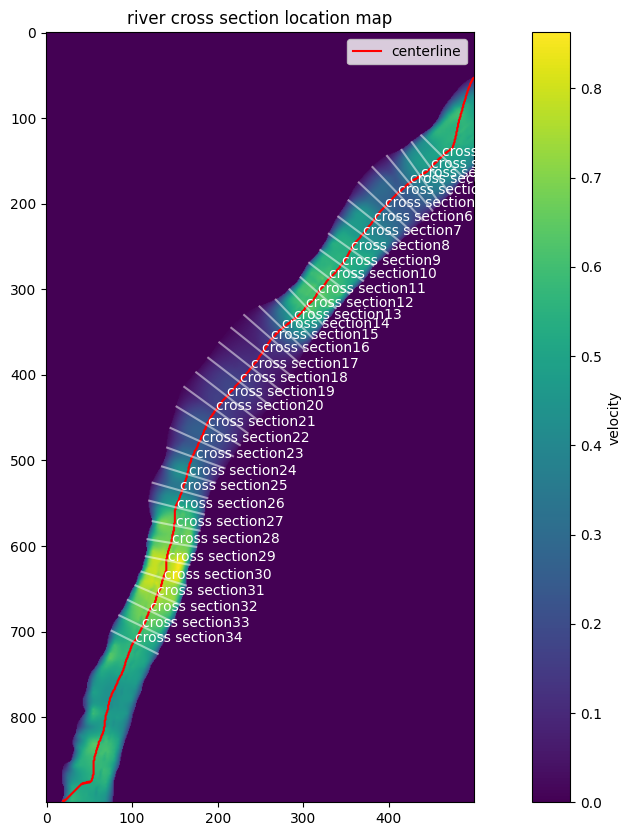

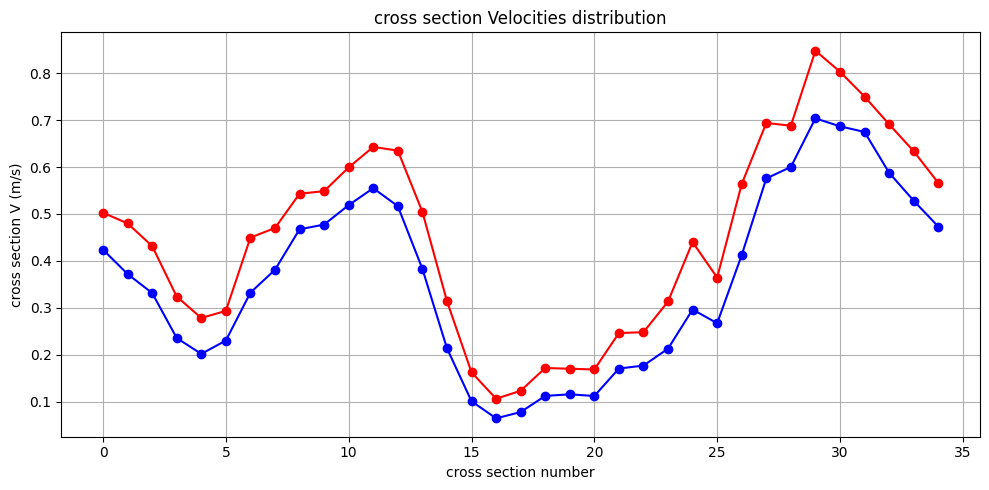

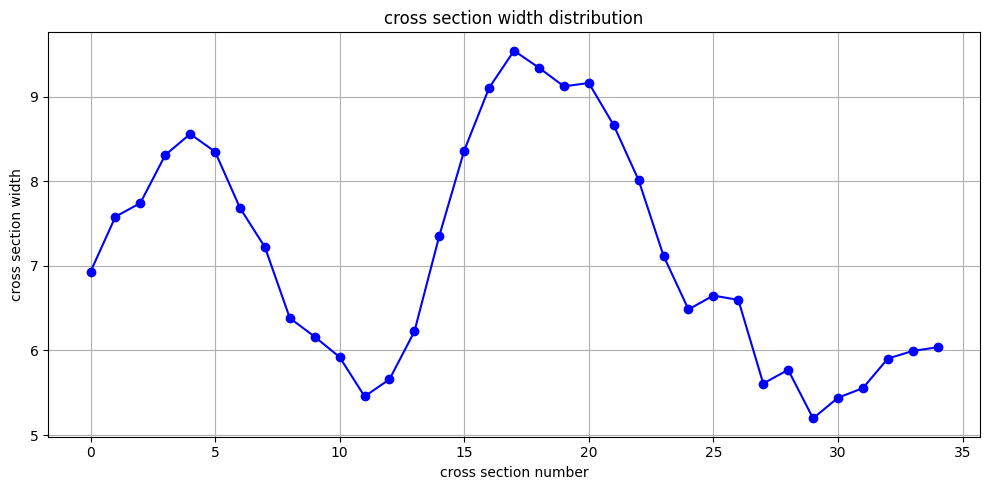


cross section information:

cross section 0:
Maxv: 0.503
minv: 0.000
averv: 0.424
numbers of points: 49

cross section 1:
Maxv: 0.480
minv: 0.000
averv: 0.372
numbers of points: 49

cross section 2:
Maxv: 0.432
minv: 0.000
averv: 0.332
numbers of points: 49

cross section 3:
Maxv: 0.324
minv: 0.000
averv: 0.236
numbers of points: 49

cross section 4:
Maxv: 0.278
minv: 0.000
averv: 0.202
numbers of points: 49

cross section 5:
Maxv: 0.294
minv: 0.000
averv: 0.230
numbers of points: 49

cross section 6:
Maxv: 0.450
minv: 0.000
averv: 0.332
numbers of points: 49

cross section 7:
Maxv: 0.470
minv: 0.000
averv: 0.381
numbers of points: 49

cross section 8:
Maxv: 0.543
minv: 0.000
averv: 0.467
numbers of points: 49

cross section 9:
Maxv: 0.549
minv: 0.000
averv: 0.477
numbers of points: 49

cross section 10:
Maxv: 0.599
minv: 0.000
averv: 0.519
numbers of points: 49

cross section 11:
Maxv: 0.643
minv: 0.000
averv: 0.555
numbers of points: 49

cross section 12:
Maxv: 0.635
minv: 0.000
ave

In [9]:
# Visualize results
# 1. Plan view showing cross-section locations
plt.figure(figsize=(15, 10))
# plt.subplot(2, 1, 1)
plt.imshow(V1, cmap='viridis')  # Use viridis colormap to show velocity
plt.colorbar(label='velocity')
plt.plot(centerline_points[:,0], centerline_points[:,1], 'r-', label='centerline')

# Plot cross-section lines
for i, (left, right) in enumerate(boundary_points):
    plt.plot([left[0], right[0]], [left[1], right[1]], 'w-', alpha=0.5)
    # Label cross-section number at midpoint
    mid_x = (left[0] + right[0]) / 2
    mid_y = (left[1] + right[1]) / 2
    plt.text(mid_x, mid_y, f'cross section{i}', color='white')

plt.title('river cross section location map')
plt.legend()

# 2. Plot average and maximum cross-section velocities
plt.figure(figsize=(10, 5))

velocities_aver,velocities_max = [],[]
for i, data in enumerate(cross_section_data):
    velocities = data['velocities']
    velocities_aver.append(np.mean(velocities))
    velocities_max.append(np.max(velocities))

plt.plot(range(len(velocities_aver)), velocities_aver, 'b-o')
plt.plot(range(len(velocities_max)), velocities_max, 'r-o')
plt.xlabel('cross section number')
plt.ylabel('cross section V (m/s)')
plt.title('cross section Velocities distribution')
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(10, 5))
plt.plot(range(len(B)), B, 'b-o')
plt.xlabel('cross section number')
plt.ylabel('cross section width')
plt.title('cross section width distribution')
plt.grid(True)
plt.tight_layout()

plt.show()

# Print basic statistics for each cross-section
print("\ncross section information:")
for i, data in enumerate(cross_section_data):
    velocities = data['velocities']
    print(f"\ncross section {i}:")
    print(f"Maxv: {np.max(velocities):.3f}")
    print(f"minv: {np.min(velocities):.3f}")
    print(f"averv: {np.mean(velocities):.3f}")
    print(f"numbers of points: {len(velocities)}")

In [4]:
import numpy as np

# Load the saved numpy file
results = np.load('river2.npy', allow_pickle=True).item()

# Access data
centerline_points = results['centerline']
smooth_cross_sections = results['cross_sections']
velocity_distributions = results['velocity_distributions']

# Print some information to verify the data
print("Number of centerline points:", len(centerline_points))
print("Number of cross-sections:", len(smooth_cross_sections))
print("Number of velocity distribution entries:", len(velocity_distributions))

# Example: access velocity distribution of the first cross-section
first_section_velocity = velocity_distributions[0]['velocities']
Y = velocity_distributions[0]['distances']
print("Positions of the first cross-section:", Y)

data_sum = []
for i in range(len(smooth_cross_sections)):
    Y = velocity_distributions[i]['distances']
    Ux = velocity_distributions[i]['velocities']
    Bx = velocity_distributions[i]['Bottom width']
    # data0 = np.vstack((Ux, Y, Bx)).ravel()
    data0 = np.concatenate((Ux, Y, [Bx]))
    data_sum.append(data0)
data_sum = np.array(data_sum).swapaxes(1, 0)
np.savetxt("realriver2.dat", data_sum)

Number of centerline points: 208
Number of cross-sections: 40
Number of velocity distribution entries: 40
Positions of the first cross-section: [0.         0.16271353 0.32542707 0.4881406  0.65085414 0.81356767
 0.97628121 1.13899474 1.30170828 1.46442181 1.62713535 1.78984888
 1.95256242 2.11527595 2.27798949 2.44070302 2.60341656 2.76613009
 2.92884363 3.09155716 3.2542707  3.41698423 3.57969777 3.7424113
 3.90512484 4.06783837 4.23055191 4.39326544 4.55597898 4.71869251
 4.88140605 5.04411958 5.20683312 5.36954665 5.53226019 5.69497372
 5.85768726 6.02040079 6.18311433 6.34582786 6.5085414  6.67125493
 6.83396847 6.996682   7.15939554 7.32210907 7.48482261 7.64753614
 7.81024968]
